In [16]:
import spacy
import pandas as pd 
import jsonlines
import spacy
from tqdm.auto import tqdm

def get_ents(text_list):
    ents = []
    for doc in tqdm(
        spacy_model.pipe(
            text_list,
            disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"]
        ), total=len(text_list)
    ):
        doc_ents = list(doc.ents)
        ents.append(doc_ents)
    return ents


spacy_model = spacy.load('en_core_web_lg')
agenda_watch_df = pd.read_csv('../data/agenda-watch-bay-area-202027.csv', index_col=0)

In [7]:
with jsonlines.open('../data/sfchron-fetched-articles.jsonl') as f:
    sfchron_data = list(f)

sfchron_article_df = pd.DataFrame(sfchron_data)

In [ ]:
sfchron_ents = get_ents(sfchron_article_df['article_text'])
list_of_sfcrhon_ents = list(map(lambda x: list(map(lambda y: (str(y), y.label_), x)), sfchron_ents))

In [64]:
# import pickle
# with open('cache/sfchron_ents.pkl', 'wb') as f:
#     pickle.dump(list_of_sfcrhon_ents, f)

In [69]:
list_of_sfcrhon_ents[5]

[('91', 'DATE'),
 ('Mike Kepka', 'PERSON'),
 ('The Chronicle Al Nalbandian', 'ORG'),
 ('Stockton', 'GPE'),
 ('these days', 'DATE'),
 ('seven', 'CARDINAL'),
 ('the Union Square Station of', 'FAC'),
 ('the Central Subway', 'FAC')]

In [ ]:
agenda_watch_ents = get_ents(agenda_watch_df['text'])
list_of_agenda_watch_ents = list(map(lambda x: list(map(lambda y: (str(y), y.label_), x)), agenda_watch_ents))

In [184]:
from more_itertools import flatten
from unidecode import unidecode
import re
import dateparser

In [215]:
all_agenda_watch_ents = list(flatten(list_of_agenda_watch_ents))

agenda_watch_dates = list(filter(lambda x: x[1] == 'DATE', all_agenda_watch_ents))
agenda_watch_parsed_dates = list(map(lambda x: dateparser.parse(x[0]), agenda_watch_dates))

agenda_watch_times = list(filter(lambda x: x[1] == 'TIME', all_agenda_watch_ents))
agenda_watch_parsed_times = list(map(lambda x: dateparser.parse(x[0]), agenda_watch_times))

all_agenda_watch_ents_to_match = list(filter(
    lambda x: x[1] not in ['CARDINAL', 'PRODUCT', 'TIME', 'DATE'], all_agenda_watch_ents
))

In [3]:
ls ~/

Applications/                Pictures/
Desktop/                     Projects/
Documents/                   Public/
Downloads/                   Zotero/
Google Drive@                go/
Library/                     java_error_in_pycharm.hprof
Movies/                      nltk_data/
Music/                       opt/


In [102]:
from rake_nltk import Rake

# Uses stopwords for english from NLTK, and all puntuation characters by
# default
r = Rake(max_length=3)
r.extract_keywords_from_sentences(sfchron_article_df['article_text'].tolist())
rake_keywords = r.get_ranked_phrases_with_scores()
rake_keywords = list(filter(lambda x: 'http :// ' not in x[1], rake_keywords))
rake_keywords = list(set(rake_keywords))
rake_keywords = sorted(rake_keywords, key=lambda x: -x[0])
rake_keywords = list(filter(lambda x: 'https ://' not in x[1], rake_keywords))

# Try to summarize with OpenAI

In [17]:
import openai
openai.api_key_path = '/Users/spangher/.openai-isi-key.txt'

In [92]:
text = agenda_watch_df['text'].iloc[7]

In [86]:
content=f"""Here is the text of a recent city council meeting minute: 
      
      "{text}"
      
      -----
      1. What were the issues discussed? Be descriptive. Return as a python list: e.g. [
          'Roll call - the attendance of the members of the Alameda Reuse and Redevelopment Authority is recorded.',
          'Consent Calendar - various items are approved by the Board without discussion, including the approval of meeting minutes, sublease for sustainable technologies, waiver of license fee for student activities, and an authorization to amend a consultant agreement.',
          'Regular Agenda Items - Friends of the Wildlife Refuge present an update on their activities at the Alameda proposed Wildlife Refuge to ensure resources are protected during transfer negotiations. The Board discusses the vulnerability of the Alameda Point and breakwater, increase in pelican numbers, and use of willows by migratory birds. The importance of the Alameda Wildlife Refuge is highlighted, with students from Los Angeles and New York conducting their graduate work at the site.',
          ...
      ]
      2. Who was present? Be concise. Return as a python list: e.g. "['Alice', 'Bob', ...]"
      """

In [58]:
import pyperclip
pyperclip.copy(content)

In [87]:
completion = openai.ChatCompletion.create(
  model="gpt-3.5-turbo", 
  messages=[{
      "role": "user",
      "content": content
#             Please remove any unimportant details such the pledge of allegiance being said.
  }]
)

In [ ]:
print(completion.to_dict_recursive()['choices'][0]['message']['content'])

In [110]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [113]:
def query_openai_city_council_meeting_minutes(text):
    content=f"""Here is the text of a recent city council meeting minute: 

          "{text}"

          -----
          1. What were the issues discussed? Be descriptive. Return as a python list: e.g. [
              'Roll call - the attendance of the members of the Alameda Reuse and Redevelopment Authority is recorded.',
              'Consent Calendar - various items are approved by the Board without discussion, including the approval of meeting minutes, sublease for sustainable technologies, waiver of license fee for student activities, and an authorization to amend a consultant agreement.',
              'Regular Agenda Items - Friends of the Wildlife Refuge present an update on their activities at the Alameda proposed Wildlife Refuge to ensure resources are protected during transfer negotiations. The Board discusses the vulnerability of the Alameda Point and breakwater, increase in pelican numbers, and use of willows by migratory birds. The importance of the Alameda Wildlife Refuge is highlighted, with students from Los Angeles and New York conducting their graduate work at the site.',
              ...
          ]
          2. Who was present? Be concise. Return as a python list: e.g. "['Alice', 'Bob', ...]"
          """
    
    num_tokens = len(tokenizer.encode(content))
    if num_tokens > 4000:
        return 
    
    completion = openai.Completion.create(
      model="text-davinci-003",
      prompt=content,
      max_tokens=4096 - num_tokens
    )
    return completion.to_dict_recursive()['choices'][0]['text']

In [114]:
tqdm.pandas()

openai_summaries = []
for text in tqdm(agenda_watch_df['text']):
    completion = query_openai_city_council_meeting_minutes(text)
    openai_summaries.append(completion)

  0%|          | 0/1073 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (5368 > 1024). Running this sequence through the model will result in indexing errors


In [647]:
print(agenda_watch_df['text'].iloc[0])

Meeting Minutes
City of Oakland Office of the City Clerk
Oakland City Hall
1 Frank H. Ogawa Plaza
Oakland, California 94612
LaTonda Simmons, City Clerk
Office of the Mayor Annual Recess Agenda
August 1, 2007 - September 4, 2007
Oakland City Hall, 1 Frank H. Ogawa Plaza, Oakland, California, 94612
City of Oakland Website: http://www.oaklandnet.com
Tuesday, August 28, 2007 8:30 AM Oakland City Hall - 3rd Floor
1 Subject: 2007-2008 Real And Personal Property Tax
From: Finance And Management Agency
Recommendation: Adopt A Resolution Fixing The Rate Of Property Tax And Levying A Tax On 
Real And Personal Property In The City Of Oakland For Fiscal Year 2007-2008 For 
Voter-Approved Indebtedness
07-0509
Adopted
View Report.pdf
80794 CMS.pdf
2 Subject: McKillop Roadway - Landslide Damage
From: Public Works Agency
Recommendation: Adopt A Resolution Renewing And Continuing The Local Emergency Due To 
Landslide Damage To McKillop Roadway First Proclaimed By The City Of Oakland On October 
17, 200

In [142]:
agenda_watch_df['openai_summaries'] = openai_summaries

In [650]:
agenda_watch_df.to_csv('../data/city-council-meeting-minutes/orig-agenda-watch-with-gpt3-summaries.csv')

In [648]:
print(openai_summaries[0])

# then pass this to turkers/journalists and ask them whether it's about the same thing or not.
# pass them a list of line-items from the agenda


Answer 1: ['2007-2008 Real and Personal Property Tax - Adopt a resolution fixing the rate of property tax and levying a tax on real and personal property in the City of Oakland for Fiscal Year 2007-2008 for voter-approved indebtedness.',
'McKillop Roadway - Landslide Damage - Adopt a resolution renewing and continuing the local emergency due to landslide damage to McKillop Roadway first proclaimed by the City of Oakland on October 17, 2006.']

Answer 2: ['LaTonda Simmons', 'Office of the Mayor']


In [239]:
agenda_watch_df_with_good_summaries = (agenda_watch_df
 .loc[lambda df: df['openai_summaries'].notnull()]
)

In [243]:
import ast

In [ ]:
print(agenda_watch_df_with_good_summaries.loc[lambda df: df['doc_type'] == 'Minutes']['text'].iloc[6])

In [ ]:
(agenda_watch_df_with_good_summaries['openai_summaries']
 .str.strip()
 .apply(lambda x: re.findall(r'\[.*?\]', x, flags=re.DOTALL))
 .loc[lambda s: s.str.len() == 2]
 .apply(lambda x: list(map(ast.literal_eval, x)))
)

In [128]:
# import pickle
# with open('cache/sfchron_rake_keywords.pkl', 'wb') as f:
#     pickle.dump(rake_keywords, f)

In [ ]:
agenda_watch_df_with_good_summaries['openai_summaries_parsed'] = (
 agenda_watch_df_with_good_summaries['openai_summaries']   
 .fillna('')
 .apply(lambda x: re.search('\[.*?\]', x.replace('\n', '')))
 .apply(lambda x: x[0] if x is not None else '')
)

In [915]:
fixed_summaries = pd.read_csv('../data/city-council-meeting-minutes/summaries-to-fix.csv', index_col=0)['fixed_summary']

In [916]:
def try_ast(x):
    try:
        return ast.literal_eval(x)
    except:
        return np.nan

In [ ]:
ls 

In [927]:
(pd.concat([agenda_watch_df_with_good_summaries, fixed_summaries], axis=1)
 .assign(parsed_summary=lambda df: 
         df
         .apply(lambda x: x['openai_summaries_parsed'] if pd.isnull(x['fixed_summary']) else x['fixed_summary'], axis=1)
         .apply(try_ast)
         .apply(lambda x: list(map(lambda y: '- ' + y, x)) if isinstance(x, list) else np.nan)
         .apply(lambda x: '\n'.join(x) if isinstance(x, list) else np.nan)
    )
 .drop('fixed_summary', axis=1)
 [['text', 'parsed_summary']]
 .rename(columns={'parsed_summary': 'summary'})
 .to_csv('../data/city-council-meeting-minutes/old-agenda-watch-with-gpt3-summaries-parsed.csv')
)

In [ ]:
pd.read_csv('../data/')

# Scrape new city-council meeting minutes

In [521]:
import glob

In [527]:
csvs_to_read = glob.glob('../bin/aw-legistar-scraper-selenium/legistar_scraper/output-20*/*')

In [528]:
all_dfs = []
for csv_file in csvs_to_read:
    one_df = pd.read_csv(csv_file, index_col=0)
    all_dfs.append(one_df)
files_to_get = pd.concat(all_dfs)

In [341]:
from PIL import Image
import pytesseract
import numpy as np
import json

In [348]:
import glob
pdf_files = glob.glob('../data/legistar-pdfs/*')

In [ ]:
import requests
from pdf2image import convert_from_bytes
import os
from PIL import Image
from pdf2image import convert_from_path
import pytesseract
import numpy as np 

resp = requests.get('https://cupertino.legistar.com/View.ashx?M=A&ID=1078486&GUID=44A0FDDF-E19E-4AFD-B86F-5D44D483BD67')
doc = convert_from_bytes(resp.content)

# loop through the pages of the pdf file and extract text
for page_number, page_data in enumerate(doc):
    page_data_array = np.asarray(page_data)
    txt = pytesseract.image_to_string(Image.fromarray(page_data_array))
    print("Page # {} - {}".format(str(page_number), txt))

In [475]:
t = requests.post(
    'https://requests-ocr-parser-v2-ukvxfz3sya-uw.a.run.app',
    headers={'Content-Type': 'application/json'},
    data=json.dumps(dat)
)

In [ ]:
doc = convert_from_bytes(resp_pdf.content)

# loop through the pages of the pdf file and extract text
all_texts= []
for page_number, page_data in tqdm(enumerate(doc), total=len(doc)):
    page_data_array = np.asarray(page_data)
    txt = pytesseract.image_to_string(Image.fromarray(page_data_array))
    all_texts.append(txt)

In [543]:
non_pdf_html = 'https://alameda.legistar.com/View.ashx?M=M&ID=718080&GUID=5C02955B-6F6E-4C7B-8571-B9013F770F8A'

In [545]:
resp = requests.get(non_pdf_html)

In [504]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(resp.text, 'lxml')
text = re.sub('\n+', '\n', soup.get_text())

# Experiment with how to summarize long meeting minutes

In [651]:
target_long_file = (
    '../data/legistar-pdfs/'
    'file-parsed__Stockton_2013-05-07_City-Council-Successor-Agency-to-'
    'the-Redevelopment-Agency-Public-Financing-Authority-Parking-'
    'Authority-Concurrent_Agenda.json'
)

In [557]:
target_output = json.load(open(target_long_file))

In [561]:
full_document = '\n'.join(target_output['data'])

In [564]:
len(tokenizer.encode(full_document))

240499

In [569]:
import openai
openai.api_key_path = "/Users/spangher/.openai-isi-key.txt"

# Load the ChatGPT model
model_engine = "text-davinci-002"
model = openai.Model(engine=model_engine)

In [617]:
def ordinal(n: int):
    if 11 <= (n % 100) <= 13:
        suffix = 'th'
    else:
        suffix = ['th', 'st', 'nd', 'rd', 'th'][min(n % 10, 4)]
    return str(n) + suffix

def get_one_page_summary(text, page_num, total_pages):
    prompt=f"""Here is the {ordinal(page_num)} page of a {total_pages}-page city council meeting:

          "{text}"

          -----
          Summarize the important points. Don't reference page-numbers.
    """

    num_tokens = len(tokenizer.encode(prompt))
    completion = openai.Completion.create(
      model="text-davinci-003",
      prompt=prompt,
      max_tokens=4096 - num_tokens
    )
    return completion.to_dict_recursive()['choices'][0]['text']

In [602]:
def summarize_document_chunks(text, max_tokens_per_split=3000, use_first_n_tokens=None, tokenizer=None):
    """Split a long document into segments based on every `max_tokens` GPT tokens."""
    # Calculate the number of tokens in the document
    tokens = tokenizer.encode(text)
    total_num_pages = int(len(tokens)/ max_tokens_per_split)
    num_tokens_to_summarize = len(tokens) 
    if use_first_n_tokens is not None:
        num_tokens_to_summarize = min(num_tokens_to_summarize, use_first_n_tokens)
    
    # Split the document into segments based on the `max_tokens` parameter
    segments = []
    start_token = 0
    page_num = 1
    while start_token < num_tokens_to_summarize:
        end_token = min(start_token + max_tokens_per_split, num_tokens_to_summarize)
        text_chunk = tokenizer.decode(tokens[start_token: end_token])
        summary = get_one_page_summary(text_chunk, page_num, total_num_pages)
        segments.append(summary)
        start_token = end_token
        page_num += 1
        
        if page_num % 10 == 0:
            print(f'finished {page_num} pages...')
        
    return segments

In [603]:
gpt_segments = summarize_document_chunks(full_document, tokenizer=tokenizer, use_first_n_tokens=100_000)

finished 10 pages...
finished 20 pages...
finished 30 pages...


In [618]:
with open('../data/legistar-pdfs/one-doc-gpt-summaries__level-one.json', 'w') as f:
    json.dump( gpt_segments, f)

In [615]:
second_level_gpt_segments = summarize_document_chunks('\n'.join(gpt_segments), tokenizer=tokenizer)

In [619]:
with open('../data/legistar-pdfs/one-doc-gpt-summaries__level-two.json', 'w') as f:
    json.dump(second_level_gpt_segments, f)

In [620]:
second_level_gpt_segments

['\nThe Stockton City Council is discussing several items during a 1-page meeting, including a loan to S.T.A.N.D. for the acquisition of the El Monte Apartments, a construction contract with MarTech for the Water System Security Improvements Project, the 2013-2014 One-Year Action Plan for the Community Development Block Grant, Home Investment Partnerships, and Emergency Solutions Grant Programs, and a general plan amendment and rezone for properties at the southeast corner of East Fremont Street and Wilson Way. The meeting also covers insurance, bond, and labor and material requirements for the Water System Security Improvements Project, a HOME Investment Partnerships Program loan to Stocktonians Taking Action to Neutralize Drugs, annual engineer’s reports, assessments, budgets and amendments for five industrial storm drainage basins, proposed budgets and assessments for two districts, and the appointment of three members to the Cultural Heritage Board.',
 "\nThe 31st page of the 80-pa

# Examine new city council meeting minutes

In [ ]:
# new_city_council_data = pd.read_json(
#     'city-council-processed.jsonl.gz',
#     lines=True,
#     compression='gzip',
# )

In [772]:
import pandas as pd 
new_city_council_data = pd.read_json(
    '../data/city-council-meeting-minutes/city-council-processed.jsonl.gz',
    lines=True,
    compression='gzip',
)

new_city_council_data= (
    new_city_council_data
        .assign(data=lambda df: df.apply(lambda x: x['data'] if not isinstance(x['data'], float) else x['pdf_data'], axis=1))
        .drop('pdf_data', axis=1)
)

In [780]:
tqdm.pandas()
num_tokens_per_doc = new_city_council_data['data'].str.join('\n').progress_apply(lambda x: len(tokenizer.encode(x)))

(num_tokens_per_doc.apply(lambda x: min(x, 3000)).iloc[:5000].sum() / 1000 ) * .02

  0%|          | 0/31892 [00:00<?, ?it/s]

In [828]:
(num_tokens_per_doc
 .loc[lambda s: s > 500]
 .loc[lambda s: s < 2000]
 .apply(lambda x: min(x, 3000))
 .iloc[:5_000]
 .pipe(lambda s: s.sum() / 1000 * .02)
)

115.84958

<AxesSubplot:>

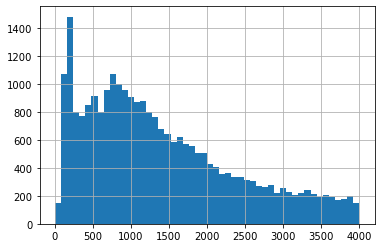

In [827]:
num_tokens_per_doc.hist(bins=50, range=(0, 4000))

<AxesSubplot:>

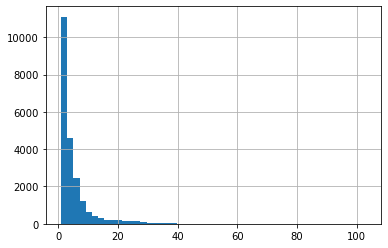

In [668]:
new_city_council_data['data'].str.len().hist(bins=50)

In [744]:
sample_short_meeting = new_city_council_data['data'].loc[lambda s: s.str.len() == 1].iloc[3][0]

In [763]:
sample_short_meeting_2 = new_city_council_data['data'].loc[lambda s: s.str.len() == 10].iloc[50][0]

In [717]:
prompt=f"""Here is the text of a recent city council meeting minute: 

          ```
          {sample_short_meeting}
          ```

          -----
          What were the issues discussed? Be descriptive. Return as a python list: e.g. [
              'Roll call - the attendance of the members of the Alameda Reuse and Redevelopment Authority is recorded.',
              'Consent Calendar - various items are approved by the Board without discussion, including the approval of meeting minutes, sublease for sustainable technologies, waiver of license fee for student activities, and an authorization to amend a consultant agreement.',
              'Regular Agenda Items - Friends of the Wildlife Refuge present an update on their activities at the Alameda proposed Wildlife Refuge to ensure resources are protected during transfer negotiations. The Board discusses the vulnerability of the Alameda Point and breakwater, increase in pelican numbers, and use of willows by migratory birds. The importance of the Alameda Wildlife Refuge is highlighted, with students from Los Angeles and New York conducting their graduate work at the site.',
              ...
          ]
"""

In [699]:
completion = openai.Completion.create(
  model="text-davinci-003",
  prompt=prompt,
  max_tokens=4096 - len(tokenizer.encode(prompt))
)

In [707]:
pyperclip.copy(prompt)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [704]:
print(completion.to_dict_recursive()['choices'][0]['text'])


[
'Roll call - the attendance of members of the Youth Advisory Commission is recorded.', 
'Approval of agenda and meeting minutes of November 18, 2013, regular meeting.', 
'Committee reports - includes special events committee, mini grant updates, and youth leadership award committee.', 
'Liaison representatives - includes representatives from the Recreation and Parks Commission and City Council.', 
'New business - includes recruiting and marketing for a talent show, ticket sales, January and February schedule, talent show schedule, and annual egg hunt (April 12, 2014).', 
'Old business - includes mixer updates and appointment.', 
'Report of Secretary - includes YAC calendar, YAC Secretary changes, and the next YAC meeting on February 18, 2014.', 
'Public Comments.', 
'Adjournment.'
]


In [718]:
completion_davinci_02 = openai.Completion.create(
  model="text-davinci-002",
  prompt=prompt,
  max_tokens=4096 - len(tokenizer.encode(prompt))
)

In [723]:
print(completion_davinci_02.to_dict_recursive()['choices'][0]['text'])


-Approval of Agenda of December 17, 2013, Regular Meeting
-Approval of Meeting Minutes of November 18, 2013, Regular Meeting
-Committee Reports
-Liaison Representatives
-New Business
-Old Business
-Report of Secretary
-Public Comments
-Adjournment


In [765]:
prompt=f"""
        You are a bot who reads agendas and summarizes them. 
        You first identify the main points of this agenda, then, rephrase each in a concise manner in with bullet points.
        
        Here's a real example:
            ```{ sample_short_meeting }```
            
        Here's what you would summarize:
            * Roll call - the attendance of members of the Youth Advisory Commission is recorded.
            * Approval of agenda and meeting minutes of November 18, 2013, regular meeting.
            * Committee reports - includes special events committee, mini grant updates, and youth leadership award committee.
            * Liaison representatives - includes representatives from the Recreation and Parks Commission and City Council.
            * New business - includes recruiting and marketing for a talent show, ticket sales, January and February schedule, talent show schedule, and annual egg hunt (April 12, 2014).
            * Old business - includes mixer updates and appointment.
            * Report of Secretary - includes YAC calendar, YAC Secretary changes, and the next YAC meeting on February 18, 2014.
            * Public Comments.
            * Adjournment.
        
        Ok, now do the same thing with this agenda:
            ```{sample_short_meeting_2}```

        Here's your summary:
        """
completion_curie = openai.Completion.create(
  model="curie",
  prompt=prompt,
  max_tokens=2048 - len(tokenizer.encode(prompt))
)

In [769]:
print(completion_curie.to_dict_recursive()['choices'][0]['text'])

  * Roll call - the attendance of members of the City Council is recorded.
         * Continued Regular Agenda item - approved the Central Avenue Complete Streets Concept.
             * Partial roll call - the attendance of council members is recorded.
             * Continued Regular Agenda item - approved the Central Avenue Complete Streets Concept.
             * Partially roll call - Deputy Mayor O'Connell spoke during argument and offered
to drop his motion if more work is done.
         * Revision to substance - PULLED.
Road safety is not related to the developer; parking on Central Avenue is ridiculous;
the stop light at the Central Avenue / Webster Street intersection is being constructed;
the bike lane on Santa Clara Avenue is obsolete; this is another emergency response;
the design is inappropriate because of the traffic and emergency response; pavement
width should protect pedestrians; we should not be making traffic safer at the
expense of pedestrians and bicyclists: Regin

In [630]:
import requests

In [642]:
resp = requests.get(
    'https://hercules.legistar.com/View.ashx?M=M&ID=869832&GUID=CA56F3FF-B9AC-45EC-84CF-B817DB1729CB',
#     'https://alameda.legistar.com/View.ashx?M=M&ID=565305&GUID=7B8A3DA9-01F2-4E62-93E9-5C13E20767F4'
#     'https://hercules.legistar.com/View.ashx?M=M&ID=834670&GUID=BCE6BE3A-AD92-496B-9EDC-7D5C6B17AB4E'
)

In [644]:
resp.headers

{'Cache-Control': 'private', 'Content-Length': '324324', 'Content-Type': 'application/pdf', 'Server': 'Microsoft-IIS/10.0', 'content-disposition': 'attachment;filename="Minutes.pdf"', 'X-Powered-By': 'ASP.NET', 'GranicusServer': 'gasmp-insweb3', 'Date': 'Thu, 16 Mar 2023 23:23:40 GMT', 'Set-Cookie': 'BIGipServerinsite.legistar.com_443=941753098.47873.0000; path=/; Httponly; Secure'}

In [ ]:
doc = convert_from_bytes(resp.content)

# loop through the pages of the pdf file and extract text
all_texts= []
for page_number, page_data in tqdm(enumerate(doc), total=len(doc)):
    page_data_array = np.asarray(page_data)
    txt = pytesseract.image_to_string(Image.fromarray(page_data_array))
    all_texts.append(txt)